# Tăng precision không cần train: ngưỡng giữ box và ensemble

Câu hỏi: có cần train lại để tăng precision không? Thí nghiệm này thử các cách **không train** trên cùng dữ liệu với
`compare_detectors.ipynb` (2 scene nuScenes trainval ngẫu nhiên, 40 keyframe, GT nuScenes):

- **Ngưỡng giữ box chung** `detection.min_score` = 0.1 (hiện tại), 0.2, 0.3, 0.4.
- **Ngưỡng theo lớp** `detection.min_score_per_class`, chọn bằng *leave-one-scene-out*: tối ưu F1 trên scene này, đo
  trên scene kia — không tune trên chính dữ liệu đánh giá.
- **Ensemble** YOLOE-26 + YOLO26 (box cả hai model cùng thấy được điểm cao hơn).

Mỗi biến thể chạy lại đúng pipeline (`python -m src.cli run --overwrite`, dùng detection đã cache, QA Agent chạy
lại) — số liệu là của sản phẩm thật, không phải lọc giả lập. Dữ liệu thô: `results/thresholds/threshold_experiment.json`.

**Cách đọc:** precision = box máy sinh đúng (khớp GT cùng lớp, IoU ≥ 0.5); recall = GT được máy tìm thấy.
FP = box người phải xoá/sửa, FN = vật người phải vẽ thêm.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RES = Path("results/thresholds") if Path("results/thresholds").exists() else Path("eval/results/thresholds")
R = json.loads((RES / "threshold_experiment.json").read_text())

FAM = {"yoloe": "YOLOE-26", "ens": "Ensemble YOLOE-26 + YOLO26"}
COLOR = {"yoloe": "#1baf7a", "ens": "#2a78d6"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9994", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})

# Chi phí thao tác ước tính (giây) — sửa theo số đo M1 thật của nhóm
SEC_REVIEW_FLAGGED = 3   # xem một box bị gắn cờ (Keep / Delete / đổi lớp)
SEC_DRAW_MISSED = 10     # vẽ tay một vật máy bỏ sót

rows = []
for name, v in R.items():
    pr, qa = v["pr"], v["qa"]
    low_n = qa["by_level"]["low"]["n"]
    flagged = qa["objects_evaluated"] - low_n
    slipped = qa["by_level"]["low"]["needs_fix"]
    rows.append({
        "Biến thể": name, "family": v["family"],
        "Ngưỡng": v["min_score"],
        "Precision": pr["precision"], "Recall": pr["recall"], "F1": pr["f1"],
        "Box máy sinh": pr["tp"] + pr["fp"], "FP (xoá/sửa)": pr["fp"], "FN (vẽ thêm)": pr["fn"],
        "mAP@0.5": v["map50"]["map"],
        "Box bị gắn cờ": flagged, "Lỗi lọt nhóm low": slipped,
        "Flag recall": qa["flag_recall"], "Flag precision": qa["flag_precision"],
        "Ước tính (phút)": round((flagged * SEC_REVIEW_FLAGGED + pr["fn"] * SEC_DRAW_MISSED) / 60, 1),
    })
df = pd.DataFrame(rows).set_index("Biến thể")
df.drop(columns=["family"]).style.format(precision=3)

,Ngưỡng,Precision,Recall,F1,Box máy sinh,FP (xoá/sửa),FN (vẽ thêm),mAP@0.5,Box bị gắn cờ,Lỗi lọt nhóm low,Flag recall,Flag precision,Ước tính (phút)
Biến thể,,,,,,,,,,,,,
yoloe@0.1,0.100,0.336,0.701,0.455,440,292,63,0.452,260,69,0.764,0.858,23.500
yoloe@0.2,0.200,0.432,0.668,0.525,326,185,70,0.439,152,66,0.643,0.783,19.300
yoloe@0.3,0.300,0.506,0.616,0.556,257,127,81,0.418,88,64,0.496,0.716,17.900
yoloe@0.4,0.400,0.547,0.578,0.562,223,101,89,0.395,69,55,0.455,0.667,18.300
yoloe@theo lớp,per-class,0.461,0.663,0.544,304,164,71,0.431,137,61,0.628,0.752,18.700
ens@0.1,0.100,0.311,0.725,0.435,492,339,58,0.478,297,80,0.764,0.872,24.500
ens@0.2,0.200,0.405,0.687,0.510,358,213,66,0.447,164,80,0.624,0.811,19.200
ens@0.3,0.300,0.498,0.654,0.566,277,139,73,0.414,88,77,0.446,0.705,16.600
ens@theo lớp,per-class,0.455,0.673,0.543,312,170,69,0.457,129,77,0.547,0.721,17.900


## Precision / recall theo ngưỡng

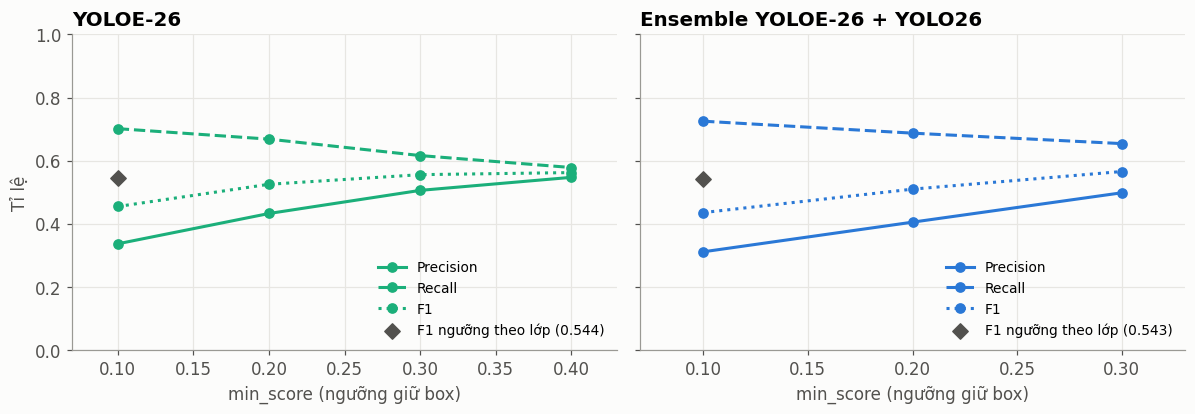

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
for ax, fam in zip(axes, FAM):
    d = df[(df.family == fam) & (df["Ngưỡng"] != "per-class")]
    x = d["Ngưỡng"].astype(float)
    for col, ls in (("Precision", "-"), ("Recall", "--"), ("F1", ":")):
        ax.plot(x, d[col], ls, marker="o", ms=6, lw=2, color=COLOR[fam], label=col)
    pc = df.loc[f"{fam}@theo lớp"]
    ax.scatter([0.1], [pc["F1"]], marker="D", s=50, color="#52514e", zorder=5, label=f"F1 ngưỡng theo lớp ({pc['F1']:.3f})")
    ax.set_title(FAM[fam])
    ax.set_xlabel("min_score (ngưỡng giữ box)")
    ax.set_xlim(0.07, x.max() + 0.03)
    ax.legend(loc="lower right", fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Tỉ lệ")
plt.tight_layout()
plt.show()

## Công của người duyệt

Nâng ngưỡng làm **ít box bị gắn cờ hơn** (ít phải xem) nhưng **nhiều vật bị sót hơn** (phải vẽ tay). Số lỗi lọt vào
nhóm low (bị duyệt theo lô mà không ai xem) gần như không đổi. Thời gian ước tính dùng
`SEC_REVIEW_FLAGGED` và `SEC_DRAW_MISSED` ở ô đầu — sửa theo số M1 thật của nhóm.

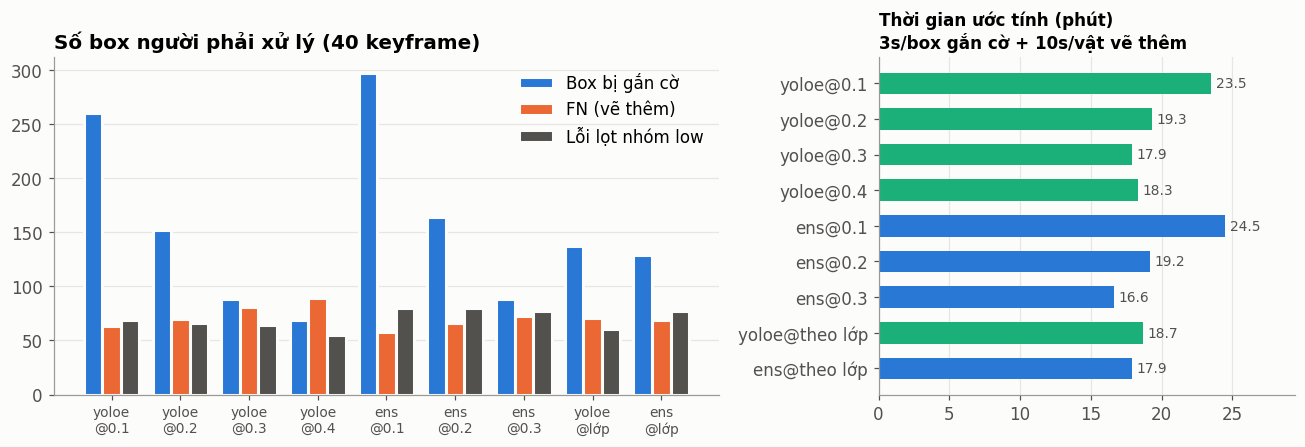

In [3]:
order = [n for n in df.index if df.loc[n, "Ngưỡng"] != "per-class"] + [n for n in df.index if df.loc[n, "Ngưỡng"] == "per-class"]
d = df.loc[order]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
x = range(len(d))
w = 0.27
ax = axes[0]
for k, (col, color) in enumerate((("Box bị gắn cờ", "#2a78d6"), ("FN (vẽ thêm)", "#eb6834"), ("Lỗi lọt nhóm low", "#52514e"))):
    ax.bar([i + (k - 1) * w for i in x], d[col], width=w, color=color, label=col, edgecolor="#fcfcfb", linewidth=2)
ax.set_xticks(list(x), [n.replace("@theo lớp", "@lớp").replace("@", "\n@") for n in d.index], fontsize=9)
ax.set_title("Số box người phải xử lý (40 keyframe)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax = axes[1]
bars = ax.barh([n for n in d.index], d["Ước tính (phút)"], color=[COLOR[f] for f in d.family], height=0.6)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9, color="#52514e")
ax.invert_yaxis()
ax.set_title(f"Thời gian ước tính (phút)\n{SEC_REVIEW_FLAGGED}s/box gắn cờ + {SEC_DRAW_MISSED}s/vật vẽ thêm", fontsize=11)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, d["Ước tính (phút)"].max() * 1.2)
plt.tight_layout()
plt.show()

## Vì sao flag recall của QA giảm khi nâng ngưỡng

Box điểm thấp là loại lỗi QA bắt dễ nhất (cờ `LOW_CONFIDENCE`). Lọc chúng đi thì số lỗi *còn lại* ít hơn nhưng khó
bắt hơn (box điểm cao mà sai lớp/lệch), nên flag recall giảm — trong khi số lỗi lọt vào nhóm low gần như không đổi.
Đây không phải QA kém đi.

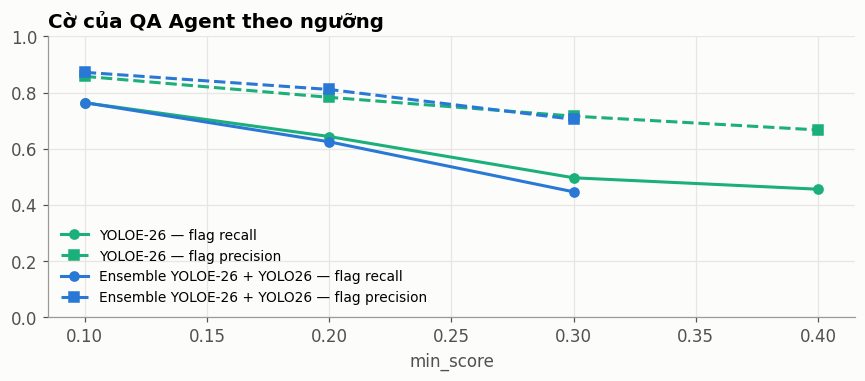

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for fam in FAM:
    d = df[(df.family == fam) & (df["Ngưỡng"] != "per-class")]
    ax.plot(d["Ngưỡng"].astype(float), d["Flag recall"], marker="o", ms=6, lw=2, color=COLOR[fam], label=f"{FAM[fam]} — flag recall")
    ax.plot(d["Ngưỡng"].astype(float), d["Flag precision"], "--", marker="s", ms=6, lw=2, color=COLOR[fam], label=f"{FAM[fam]} — flag precision")
ax.set_ylim(0, 1)
ax.set_xlabel("min_score")
ax.set_title("Cờ của QA Agent theo ngưỡng")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

## Kết luận (lần chạy 2026-09-28)

**Không cần train để tăng precision.** Chỉ cần nâng ngưỡng giữ box, precision đã tăng rõ và công của người duyệt giảm.

- **Ngưỡng 0.1 → 0.3 (YOLOE):** precision 0.34 → 0.51, F1 0.455 → 0.556. Số box bị gắn cờ phải xem giảm từ 260 xuống 88. Đổi lại máy sót thêm 18 vật (FN 63 → 81). Số lỗi lọt vào nhóm low gần như không đổi (69 → 64). Thời gian ước tính cho 40 keyframe giảm từ 23.5 xuống 17.9 phút (−24%).
- **Ngưỡng 0.4:** precision lên 0.55 nhưng sót 89 vật, thời gian không giảm thêm. Vì vậy **0.3 là điểm hợp lý**.
- **Ngưỡng theo lớp không hơn ngưỡng chung** khi đo công bằng (leave-one-scene-out): F1 0.544 so với 0.556 của ngưỡng chung 0.3. Một scene 20 keyframe quá ít để chọn ngưỡng riêng cho từng lớp. Nên thử lại khi có nhiều scene hơn.
- **Ensemble YOLOE + YOLO26 ở ngưỡng 0.3:** F1 cao nhất (0.566), recall 0.654, tức hơn YOLOE@0.3 3.8 điểm (sót 73 so với 81 vật), và thời gian thấp nhất (16.6 phút). Đổi lại, detect chậm khoảng 1.6 lần vì chạy hai model. Lan truyền không đổi (50/52 đúng).
- **mAP giảm nhẹ khi nâng ngưỡng** (0.45 → 0.42) là bình thường: mAP tính trên cả đường precision-recall, còn cắt ngưỡng thì bỏ mất phần recall cao. Chỉ số cần nhìn cho sản phẩm là precision, recall và công người duyệt ở đúng ngưỡng đang dùng.
- **Đề xuất:** đặt `min_score: 0.3` cho YOLOE. Bật ensemble `[yoloe, yolo26]` nếu máy có GPU. Chỉ tính đến fine-tune khi chạy nhiều scene hơn mà vẫn có một lớp kém kéo dài.
- **Giới hạn:** 40 keyframe, 2 scene. Thời gian ước tính giả định 3 s/box gắn cờ và 10 s/vật vẽ thêm (sửa ở ô đầu notebook).


## Chạy lại

Sau khi đã `run` + `detect-sweeps` cho các scene (mỗi detector một workspace, xem `compare_detectors.ipynb`), đổi
`detection.min_score` / `min_score_per_class` trong `configs/autolabel.yaml` rồi:

```powershell
python -m src.cli run --scenes scene-0031 scene-0065 --overwrite   # dùng detection đã cache, không detect lại
python -m src.cli evaluate
```

`evaluate` in precision / recall / F1 ở ngưỡng đang dùng (khối `pr` trong `autolabel2d_eval.json`).